In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [18]:
titanic = sns.load_dataset("titanic")

In [19]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [21]:
titanic = titanic.drop(['sibsp', 'parch' , 'class' , 'who' , 'adult_male' , 'deck' , 'embark_town' , 'alive' , 'alone'], axis=1)

In [22]:
titanic.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [23]:
titanic.isnull().sum()

survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64

In [24]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [25]:
titanic.isnull().sum()

survived    0
pclass      0
sex         0
age         0
fare        0
embarked    0
dtype: int64

In [26]:
# encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [27]:
titanic.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,1,22.0,7.2500,2
1,1,1,0,38.0,71.2833,0
2,1,3,0,26.0,7.9250,2
3,1,1,0,35.0,53.1000,2
4,0,3,1,35.0,8.0500,2


In [28]:
# Separate target 
X = titanic.drop('survived', axis=1)   # all other columns
y = titanic['survived']          # target column



In [29]:
X_train , X_test , Y_train , Y_test = train_test_split(
    X,y, test_size=0.3 , random_state=42
)


In [30]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [33]:
from sklearn.tree import    DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train , Y_train)

DecisionTreeClassifier()

In [35]:
# decision tree model

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("accuracy:" , accuracy_score(Y_test, y_pred))

accuracy: 0.7649253731343284


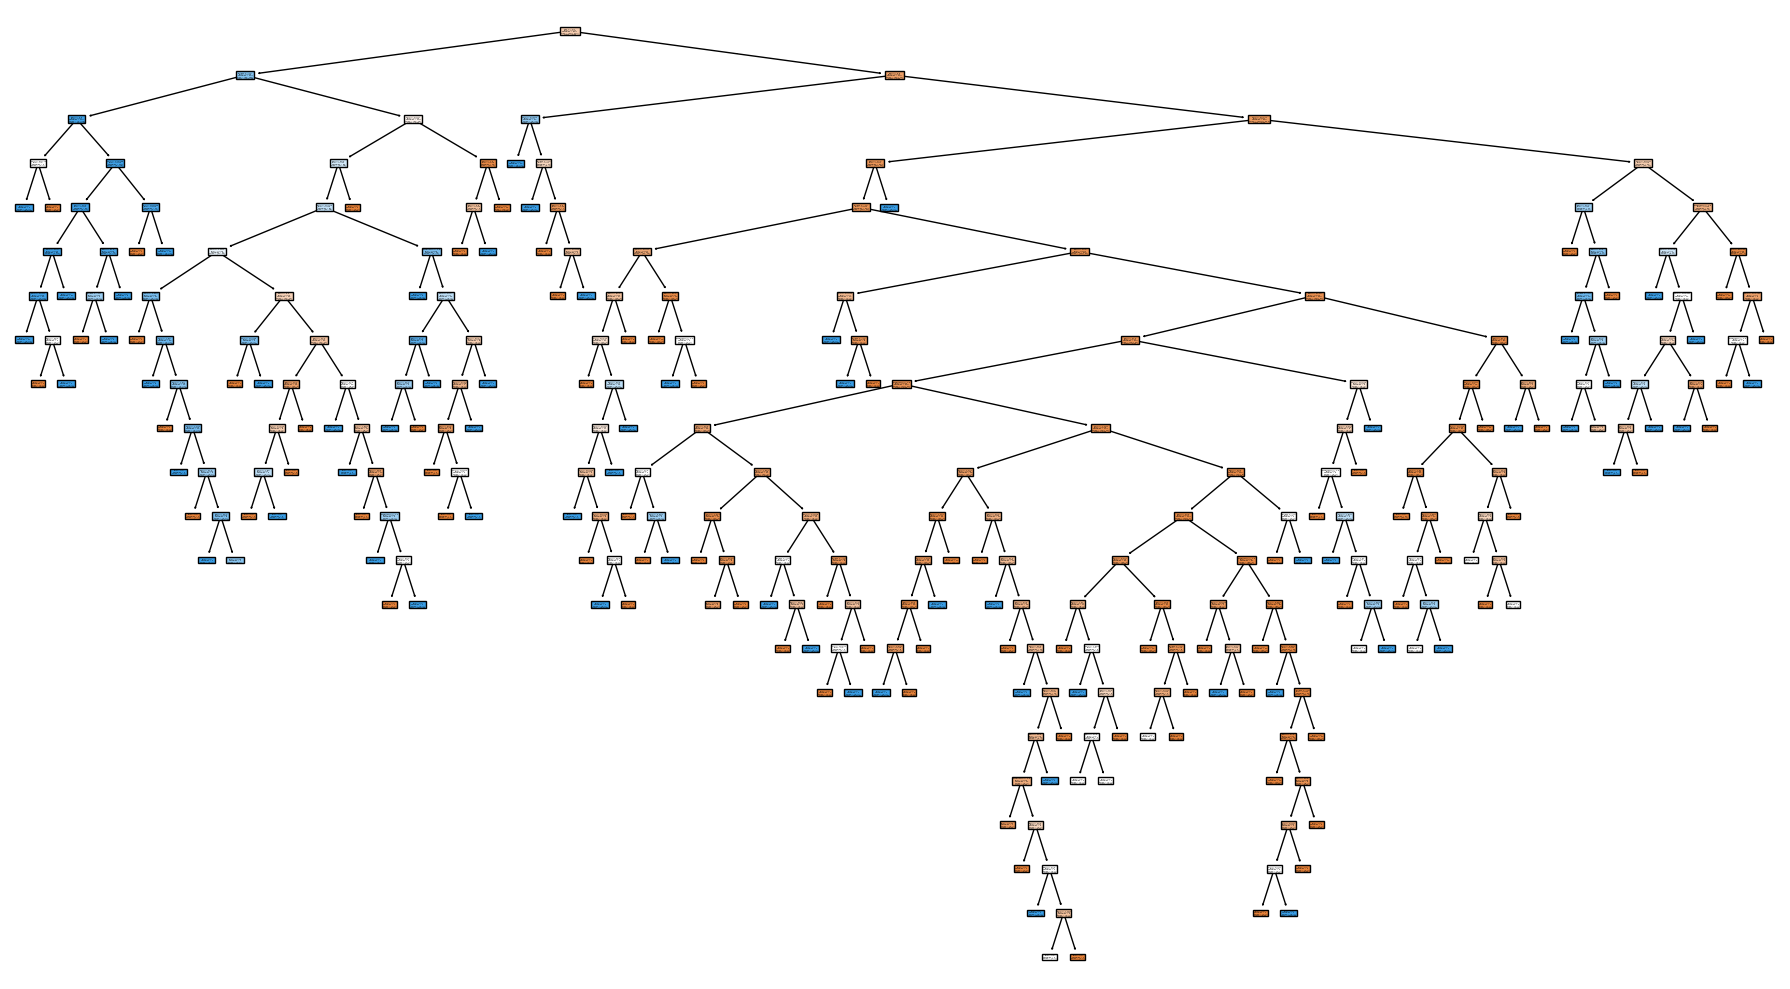

In [40]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
   # max_depth=3
)

plt.tight_layout()
plt.show()

# Decision Tree with pre-pruning

for depth=2, accuracy=0.7723880597014925
for depth=3, accuracy=0.8059701492537313
for depth=4, accuracy=0.8246268656716418


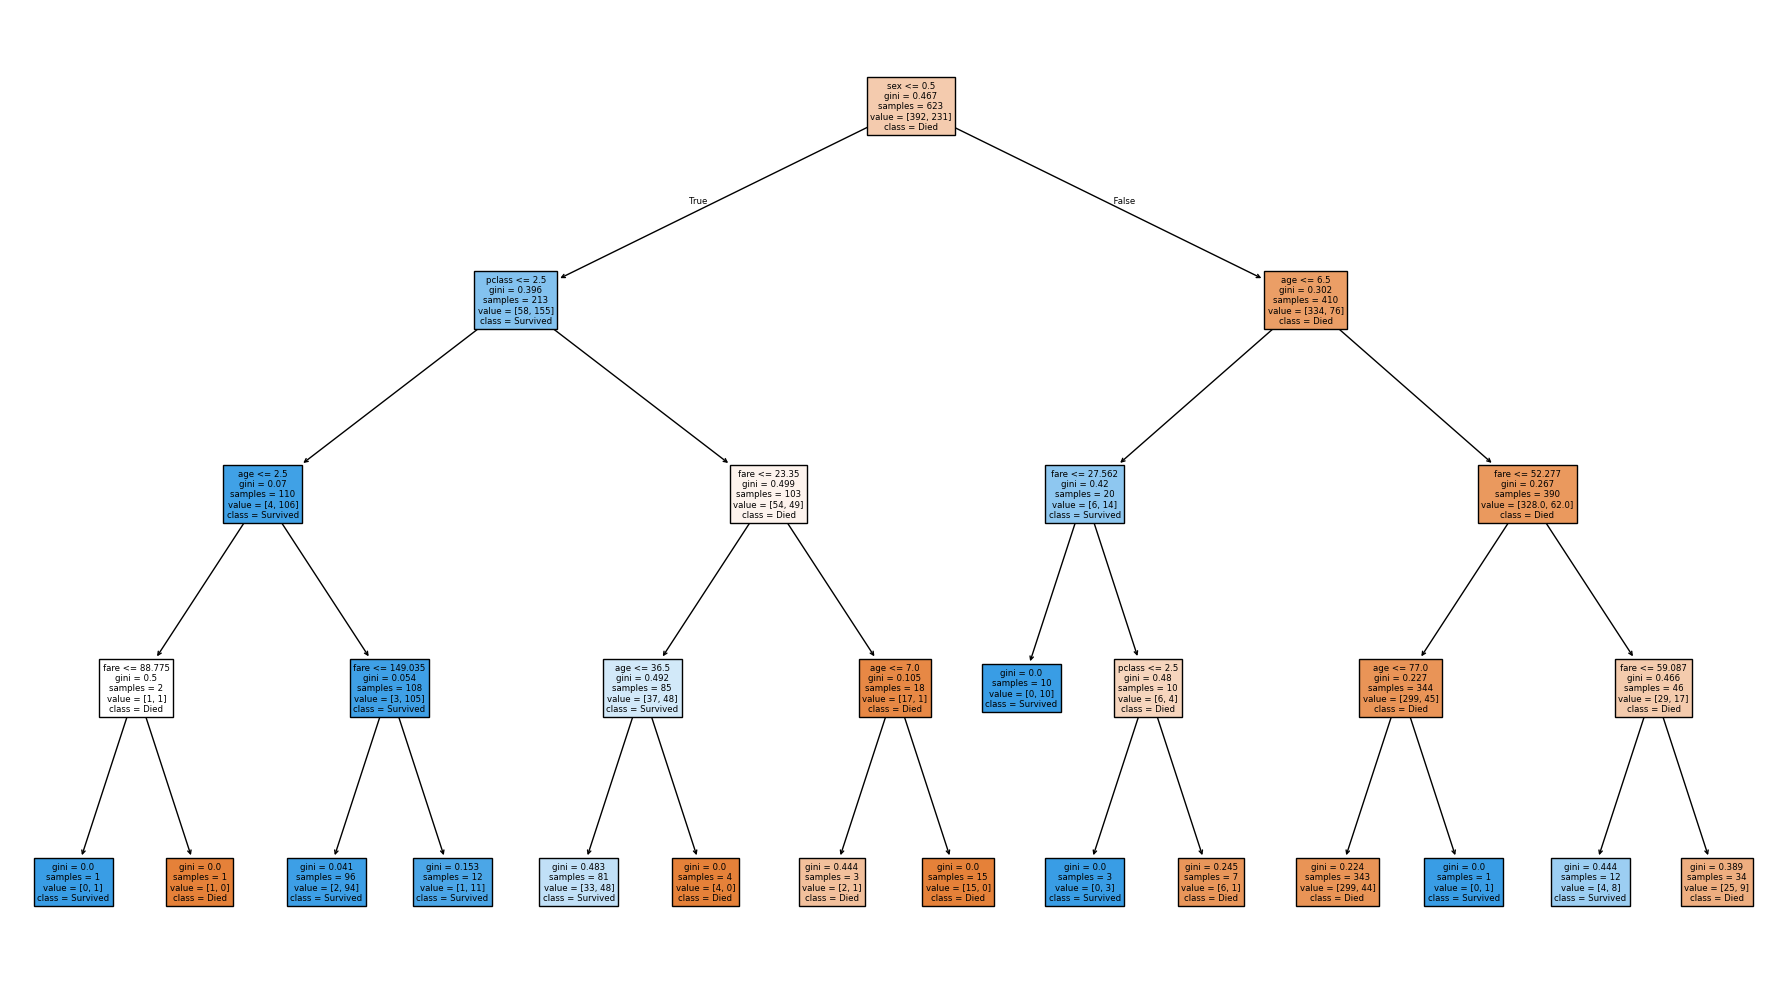

for depth=5, accuracy=0.7947761194029851
for depth=6, accuracy=0.7835820895522388
for depth=7, accuracy=0.7835820895522388
for depth=8, accuracy=0.7985074626865671
for depth=9, accuracy=0.7649253731343284
for depth=10, accuracy=0.7798507462686567


In [43]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, Y_train)

    acc = model.score(X_test, Y_test)
    print(f"for depth={depth}, accuracy={acc}")

    if depth==4:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

for sample split=5, accuracy=0.8246268656716418
for sample split=10, accuracy=0.8246268656716418


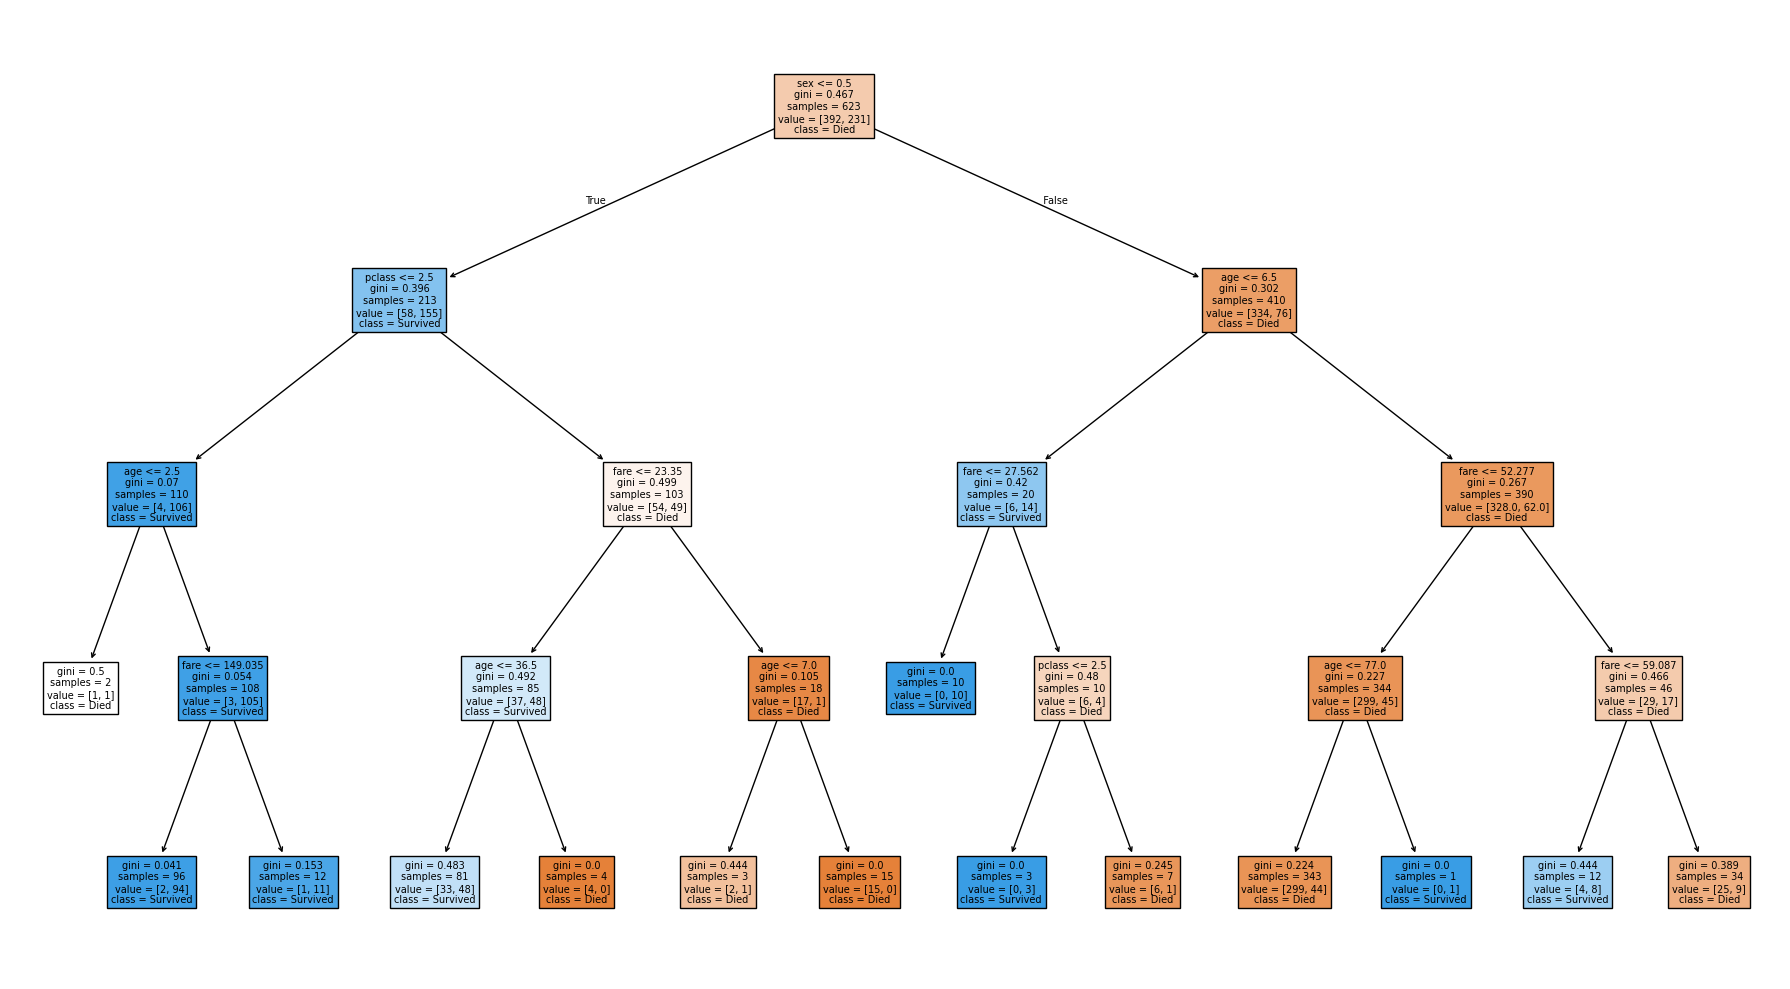

for sample split=15, accuracy=0.8171641791044776
for sample split=20, accuracy=0.8171641791044776
for sample split=25, accuracy=0.8208955223880597
for sample split=30, accuracy=0.8208955223880597


In [45]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, Y_train)

    acc = model.score(X_test, Y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

In [47]:
model = DecisionTreeClassifier(max_depth=4, min_samples_split=10)
model.fit(X_train,Y_train)


DecisionTreeClassifier(max_depth=4, min_samples_split=10)

In [48]:
y_pred = model.predict(X_test)

print("accuracy:" , accuracy_score(Y_test, y_pred))

accuracy: 0.8246268656716418
